In [215]:

# библиотеки
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import scipy.stats as sts
from itertools import combinations
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [216]:
# load data
%store -r data top_genres top_themes

top_genres = top_genres['Genre'].unique()
print(len(data))

1000


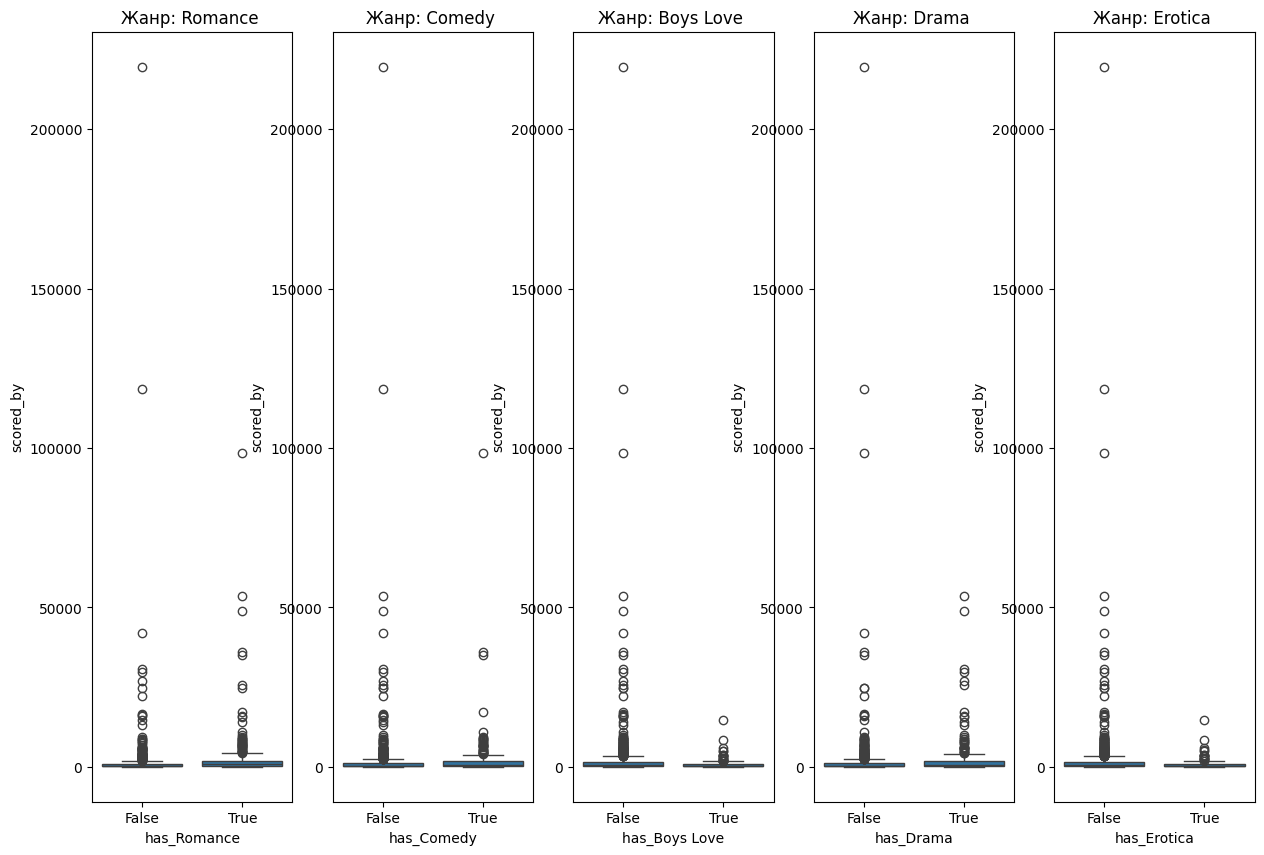

In [217]:
fig, axes = plt.subplots(1, len(top_genres),figsize=(15, 10))  # 1 строкa, 5 столбцов
for i, genre in enumerate(top_genres):
    data[f'has_{genre}'] = data['genres'].apply(lambda x: genre in x)
    sns.boxplot(x=f'has_{genre}', y='scored_by', data=data, ax=axes[i])
    axes[i].set_title(f'Жанр: {genre} ')

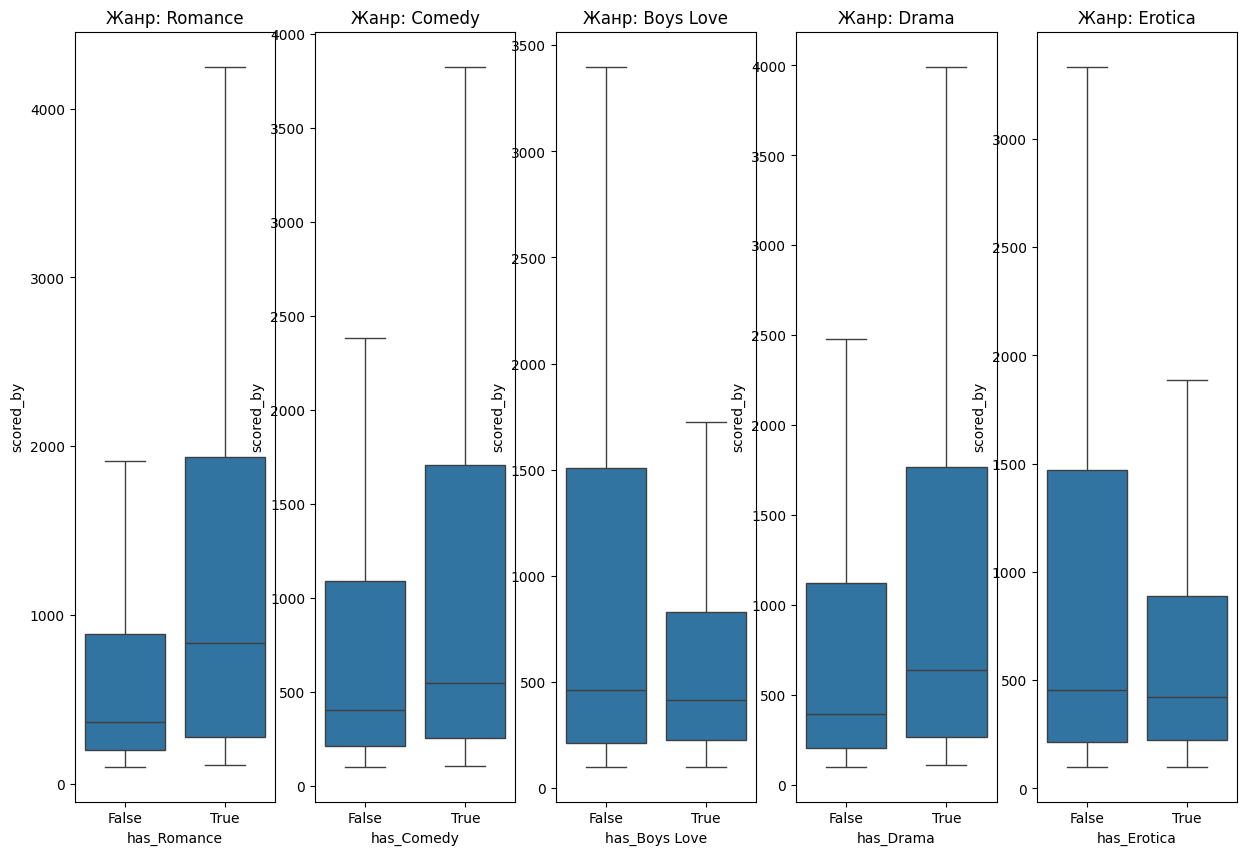

In [218]:
fig, axes = plt.subplots(1, len(top_genres),figsize=(15, 10))  # 1 строкa, 5 столбцов
for i, genre in enumerate(top_genres):
    data[f'has_{genre}'] = data['genres'].apply(lambda x: genre in x)
    sns.boxplot(x=f'has_{genre}', y='scored_by', data=data, ax=axes[i], showfliers=False)
    axes[i].set_title(f'Жанр: {genre}')

In [219]:
data['is_romance'] = data['genres'].apply(lambda x: 1 if 'Romance' in x else 0)
print(data['is_romance'].value_counts())
romance_scores = data[data['is_romance'] == 1]['scored_by']
non_romance_scores = data[data['is_romance'] == 0]['scored_by']

is_romance
0    668
1    332
Name: count, dtype: int64


In [220]:
# Проверка нормальности
_, p_romance = sts.shapiro(romance_scores)
_, p_non_romance = sts.shapiro(non_romance_scores)
print(f"Romance: {'Нормальное' if p_romance > 0.05 else 'Не нормальное'}")
print(f"Non-Romance: {'Нормальное' if p_non_romance > 0.05 else 'Не нормальное'}")

Romance: Не нормальное
Non-Romance: Не нормальное


In [221]:
# Проверка гомогенности дисперсий (Левене)
_, p_levene = sts.levene(romance_scores, non_romance_scores)
print(f"\nТест Левена: p-value = {p_levene:.3f}")
if p_levene > 0.05:
    print("Дисперсии однородны → t-тест.")
else:
    print("Дисперсии неоднородны → тест Уэлча.")


Тест Левена: p-value = 0.210
Дисперсии однородны → t-тест.


In [222]:
# t-тест (если нормальность и гомогенность)
print(p_romance,p_non_romance,p_levene)
if p_romance > 0.05 and p_non_romance > 0.05 and p_levene > 0.05:
    t_stat, p_ttest = sts.ttest_ind(romance_scores, non_romance_scores)
    print(f"\nРезультат t-теста: p-value = {p_ttest:.3f}")
    if p_ttest < 0.05:
        print("Есть статистически значимая разница в scored_by между Romance и Non-Romance.")
    else:
        print("Нет значимой разницы.")
else:
    # Непараметрический тест (Манна-Уитни)
    u_stat, p_mannwhitney = sts.mannwhitneyu(romance_scores, non_romance_scores)
    print(f"\nРезультат теста Манна-Уитни: p-value = {p_mannwhitney:.3f}")
    if p_mannwhitney < 0.05:
        print("Есть статистически значимая разница.")
    else:
        print("Нет значимой разницы.")

1.3571658608396477e-33 4.472937678944778e-48 0.21003449785553385

Результат теста Манна-Уитни: p-value = 0.000
Есть статистически значимая разница.


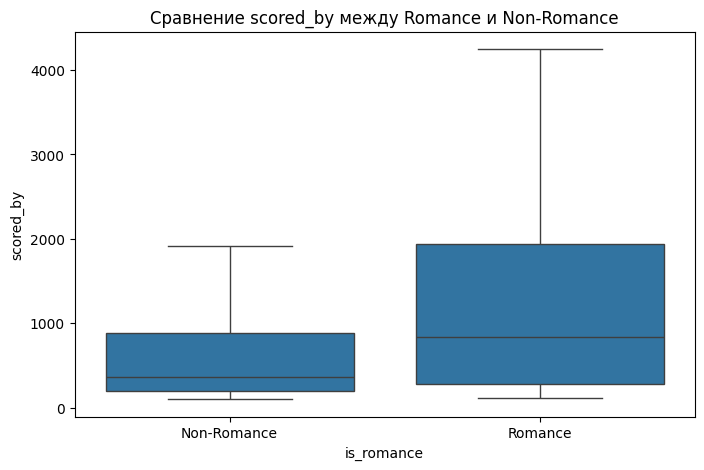

In [223]:
# Визуализация
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_romance', y='scored_by', data=data, showfliers=False)
plt.xticks([0, 1], ['Non-Romance', 'Romance'])
plt.title('Сравнение scored_by между Romance и Non-Romance')
plt.show()